TABLE 6: Gambling Participation Rates (Section 6.1)
  Age Bracket        Male   Female
  ------------------------------
  18-24              45%     15%
  25-34              52%     18%
  35-49              48%     14%
  50-64              25%      8%
  65+                10%      3%

TABLE 5: Risk Tolerance → Gambling Behavior (Section 6.2–6.3)
   Risk  Wager Mult  House Edge Bet Type                      Bets/yr
  --------------------------------------------------------------------
      1          1×        4.5% Mostly spreads                     50
      2          2×        5.5% Spreads + some props              100
      3          4×        8.0% Props + small parlays             200
      4          7×       12.0% Parlays + live betting            350
      5         12×       18.0% Heavy parlays, longshots          500

TABLE 7: Expected Annual Gambling Gain/Loss (Section 6.5)
Profile                            DI  Risk     Wager   Edge    E[Loss]  P(win)
----------------------

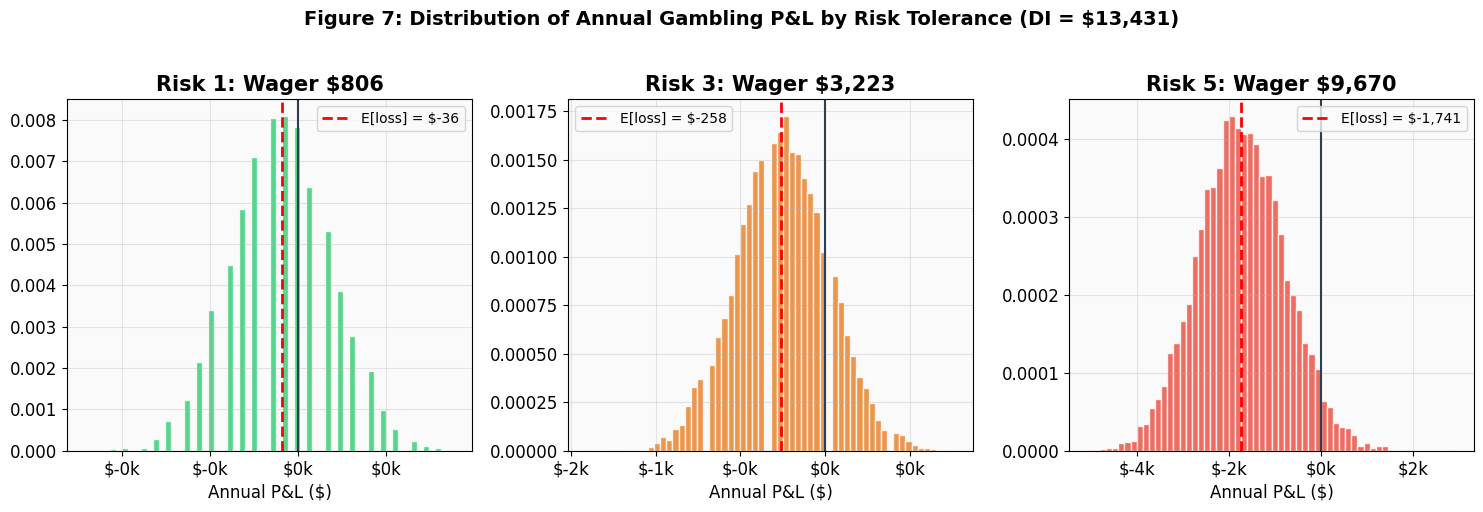

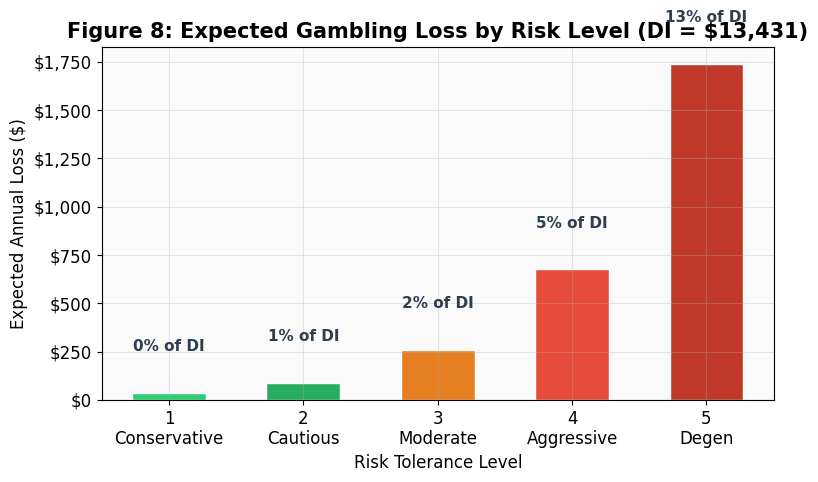

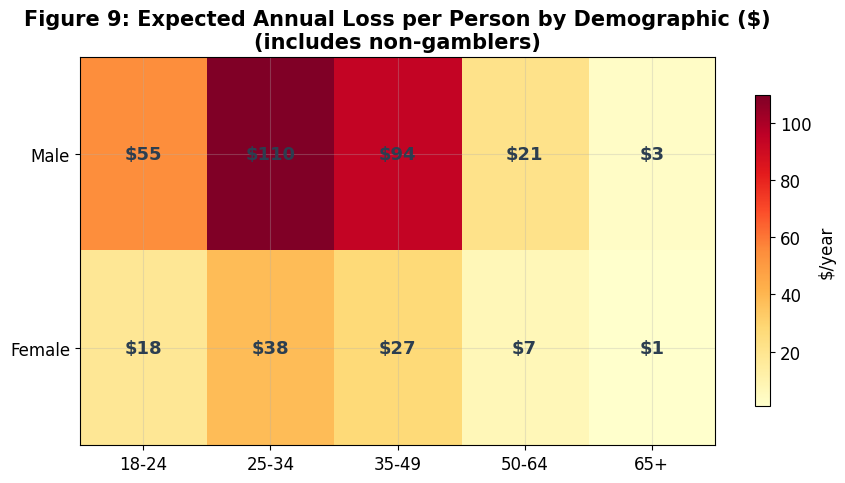

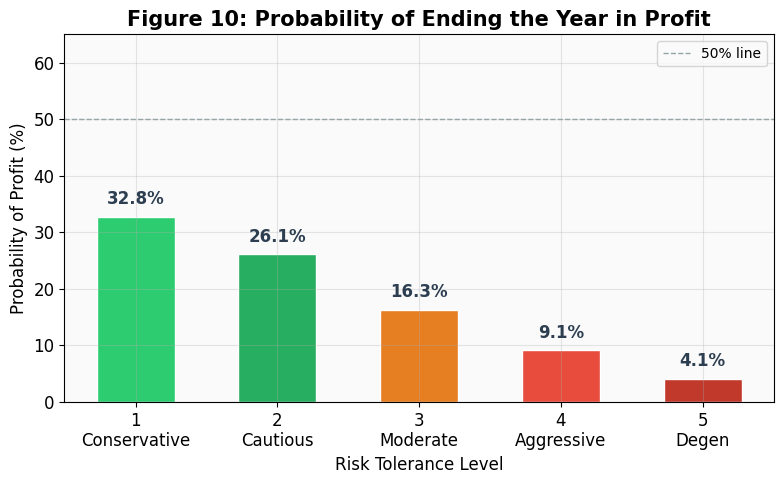


✓ Q2 complete: Tables 5–8, Figures 7–10 all produced.
  Variables 'simulate_year', 'annual_wager', 'expected_loss', 'EDGE_BY_RISK',
  'RISK_MULTIPLIERS', 'BETS_PER_YEAR', 'BASE_WAGER_FRAC' available for Q3.


In [ ]:

np.random.seed(42)


participation = {
    (18,25): {'M': 0.45, 'F': 0.15},
    (25,35): {'M': 0.52, 'F': 0.18},
    (35,50): {'M': 0.48, 'F': 0.14},
    (50,65): {'M': 0.25, 'F': 0.08},
    (65,99): {'M': 0.10, 'F': 0.03},
}

def get_participation(age, gender):
    for (lo, hi), rates in participation.items():
        if lo <= age < hi:
            return rates[gender]
    return 0.05

# --- Print TABLE 6 ---
print("TABLE 6: Gambling Participation Rates (Section 6.1)")
print(f"  {'Age Bracket':<14} {'Male':>8} {'Female':>8}")
print("  " + "-"*30)
age_bracket_labels = ['18-24','25-34','35-49','50-64','65+']
for lbl, bracket in zip(age_bracket_labels, participation.keys()):
    print(f"  {lbl:<14} {participation[bracket]['M']:>7.0%} {participation[bracket]['F']:>7.0%}")


BASE_WAGER_FRAC = 0.06

RISK_MULTIPLIERS = {1: 1.0, 2: 2.0, 3: 4.0, 4: 7.0, 5: 12.0}

def annual_wager(disposable_income, risk_tolerance):
    """Annual total amount wagered (Eq. 6)."""
    if disposable_income <= 0:
        base = 2000
    else:
        base = disposable_income * BASE_WAGER_FRAC
    return base * RISK_MULTIPLIERS[risk_tolerance]


EDGE_BY_RISK = {
    1: 0.045,   # spread bets
    2: 0.055,   # spreads + props
    3: 0.080,   # props + small parlays
    4: 0.120,   # parlays + live
    5: 0.180,   # heavy parlays, longshots
}

# --- Print TABLE 5: Risk → behavior mapping ---
print("\nTABLE 5: Risk Tolerance → Gambling Behavior (Section 6.2–6.3)")
print(f"  {'Risk':>5} {'Wager Mult':>11} {'House Edge':>11} {'Bet Type':<28} {'Bets/yr':>8}")
print("  " + "-"*68)
BETS_PER_YEAR = {1: 50, 2: 100, 3: 200, 4: 350, 5: 500}
bet_types = ['Mostly spreads','Spreads + some props','Props + small parlays',
             'Parlays + live betting','Heavy parlays, longshots']
for r in range(1,6):
    print(f"  {r:>5} {RISK_MULTIPLIERS[r]:>10.0f}× {EDGE_BY_RISK[r]*100:>10.1f}% "
          f"{bet_types[r-1]:<28} {BETS_PER_YEAR[r]:>8}")


def simulate_year(wager, risk, n_sims=10000):
    """Simulate annual P&L for n_sims bettors (Section 6.4)."""
    n_bets = BETS_PER_YEAR[risk]
    bet_size = wager / n_bets
    edge = EDGE_BY_RISK[risk]
    if risk <= 2:   payout_mult = 1.0
    elif risk <= 3: payout_mult = 1.5
    elif risk <= 4: payout_mult = 3.0
    else:           payout_mult = 6.0
    p_win = (1 - edge) / (1 + payout_mult)
    wins = np.random.binomial(n_bets, p_win, size=n_sims)
    losses = n_bets - wins
    return wins * payout_mult * bet_size - losses * bet_size

def expected_loss(wager, risk):
    """Deterministic expected annual loss (Eq. 7)."""
    return -wager * EDGE_BY_RISK[risk]

q2_profiles = [
    ('Young Male, Low Risk',      25, 'M', 13431, 1, 'US'),
    ('Young Male, Med Risk',      25, 'M', 13431, 3, 'US'),
    ('Young Male, High Risk',     25, 'M', 13431, 5, 'US'),
    ('Mid-Career Female',         42, 'F', 28982, 2, 'UK'),
    ('Senior, Conservative',      68, 'M',  9876, 1, 'US'),
    ('Young, Negative DI',        22, 'M', -11620, 4, 'US'),
]

print("\n" + "="*95)
print("TABLE 7: Expected Annual Gambling Gain/Loss (Section 6.5)")
print("="*95)
print(f"{'Profile':<28} {'DI':>8} {'Risk':>5} {'Wager':>9} {'Edge':>6} {'E[Loss]':>10} {'P(win)':>7}")
print("-"*95)

sim_results = {}
for label, age, gender, di, risk, country in q2_profiles:
    p = get_participation(age, gender)
    w = annual_wager(di, risk)
    el = expected_loss(w, risk)
    pnl = simulate_year(w, risk)
    p_profit = np.mean(pnl > 0)
    sim_results[label] = {'pnl': pnl, 'wager': w, 'el': el, 'risk': risk, 'di': di}
    print(f"  {label:<26} ${di:>7,.0f} {risk:>5} ${w:>8,.0f} {EDGE_BY_RISK[risk]*100:>5.1f}% "
          f"${el:>9,.0f} {p_profit:>6.1%}")

print("\n" + "="*95)
print("TABLE 8: Outcome Variability — 10,000 Simulated Seasons (Section 6.5)")
print("="*95)
print(f"  {'Profile':<28} {'Best 5%':>10} {'Median':>10} {'Worst 5%':>10} {'Worst 1%':>10}")
print("  " + "-"*70)
for label in sim_results:
    pnl = sim_results[label]['pnl']
    print(f"  {label:<28} ${np.percentile(pnl,95):>9,.0f} ${np.median(pnl):>9,.0f} "
          f"${np.percentile(pnl,5):>9,.0f} ${np.percentile(pnl,1):>9,.0f}")


print("\n" + "="*95)
print("POPULATION-LEVEL VALIDATION (Section 6.6)")
print("="*95)

us_pop = {
    (18,25): {'M': 15.0, 'F': 14.5}, (25,35): {'M': 23.0, 'F': 22.5},
    (35,50): {'M': 32.0, 'F': 31.5}, (50,65): {'M': 31.0, 'F': 32.0},
    (65,99): {'M': 24.0, 'F': 28.0},
}
avg_di   = {(18,25):5000, (25,35):13000, (35,50):20000, (50,65):15000, (65,99):8000}
avg_risk = {(18,25):3.2,  (25,35):2.8,   (35,50):2.3,   (50,65):1.8,   (65,99):1.3}

total_losses = 0; total_gamblers = 0
for bracket, pops in us_pop.items():
    for gender in ['M','F']:
        pop_m = pops[gender]; p_rate = participation[bracket][gender]
        n_gamblers = pop_m * p_rate; di = avg_di[bracket]; risk_avg = avg_risk[bracket]
        r_lo, r_hi = int(risk_avg), min(int(risk_avg)+1, 5); frac = risk_avg - r_lo
        rm = RISK_MULTIPLIERS[r_lo]*(1-frac) + RISK_MULTIPLIERS[r_hi]*frac
        edge = EDGE_BY_RISK[r_lo]*(1-frac) + EDGE_BY_RISK[r_hi]*frac
        bracket_loss = n_gamblers * di * BASE_WAGER_FRAC * rm * edge
        total_losses += bracket_loss; total_gamblers += n_gamblers

print(f"  Estimated US gamblers:      {total_gamblers:.1f} million")
print(f"  Estimated total US losses:  ${total_losses:,.0f} million")
print(f"  Actual US industry revenue: ~$15,000 million")
print(f"  Model / Actual ratio:       {total_losses/15000:.2f}")
print(f"  Average loss per gambler:   ${total_losses/total_gamblers*1000:,.0f}/year")


fig7, axes = plt.subplots(1, 3, figsize=(15, 5))
risk_profiles_plot = [
    ('Young Male, Low Risk', '#2ecc71'),
    ('Young Male, Med Risk', '#e67e22'),
    ('Young Male, High Risk', '#e74c3c'),
]
for ax, (label, color) in zip(axes, risk_profiles_plot):
    r = sim_results[label]; pnl = r['pnl']
    ax.hist(pnl, bins=60, color=color, alpha=0.8, edgecolor='white', density=True)
    ax.axvline(0, color='#2c3e50', linewidth=1.5, linestyle='-')
    ax.axvline(r['el'], color='red', linewidth=2, linestyle='--', label=f"E[loss] = ${r['el']:,.0f}")
    ax.set_title(f"Risk {r['risk']}: Wager ${r['wager']:,.0f}")
    ax.set_xlabel('Annual P&L ($)'); ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
fig7.suptitle('Figure 7: Distribution of Annual Gambling P&L by Risk Tolerance (DI = $13,431)',
              fontsize=14, fontweight='bold', y=1.02)
fig7.tight_layout(); plt.show()

fig8, ax8 = plt.subplots(figsize=(8, 5))
risks = [1,2,3,4,5]
risk_labels = ['1\nConservative','2\nCautious','3\nModerate','4\nAggressive','5\nDegen']
di_example = 13431
wagers = [annual_wager(di_example, r) for r in risks]
losses = [-expected_loss(w, r) for w, r in zip(wagers, risks)]
loss_pct_di = [l/di_example*100 for l in losses]
bar_colors = ['#2ecc71','#27ae60','#e67e22','#e74c3c','#c0392b']
bars8 = ax8.bar(risk_labels, losses, color=bar_colors, width=0.55, edgecolor='white')
for bar, pct in zip(bars8, loss_pct_di):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{pct:.0f}% of DI', ha='center', va='bottom', fontsize=11,
             fontweight='bold', color='#2c3e50')
ax8.set_ylabel('Expected Annual Loss ($)', fontsize=12)
ax8.set_xlabel('Risk Tolerance Level', fontsize=12)
ax8.set_title(f'Figure 8: Expected Gambling Loss by Risk Level (DI = ${di_example:,})')
ax8.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
fig8.tight_layout(); plt.show()

fig9, ax9 = plt.subplots(figsize=(9, 5))
age_labels_heat = ['18-24','25-34','35-49','50-64','65+']
brackets = [(18,25),(25,35),(35,50),(50,65),(65,99)]
matrix = np.zeros((2, 5))
for j, bracket in enumerate(brackets):
    for i, gender in enumerate(['M','F']):
        p = participation[bracket][gender]; di = avg_di[bracket]
        risk_avg = avg_risk[bracket]; r_lo = int(risk_avg); frac = risk_avg - r_lo
        rm = RISK_MULTIPLIERS[r_lo]*(1-frac) + RISK_MULTIPLIERS[min(r_lo+1,5)]*frac
        edge = EDGE_BY_RISK[r_lo]*(1-frac) + EDGE_BY_RISK[min(r_lo+1,5)]*frac
        matrix[i, j] = di * BASE_WAGER_FRAC * rm * edge * p

im = ax9.imshow(matrix, cmap='YlOrRd', aspect='auto')
ax9.set_xticks(range(5)); ax9.set_xticklabels(age_labels_heat, fontsize=12)
ax9.set_yticks([0,1]); ax9.set_yticklabels(['Male','Female'], fontsize=12)
for i in range(2):
    for j in range(5):
        ax9.text(j, i, f'${matrix[i,j]:,.0f}', ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if matrix[i,j] > 150 else '#2c3e50')
ax9.set_title('Figure 9: Expected Annual Loss per Person by Demographic ($)\n(includes non-gamblers)')
plt.colorbar(im, ax=ax9, label='$/year', shrink=0.8)
fig9.tight_layout(); plt.show()

fig10, ax10 = plt.subplots(figsize=(8, 5))
p_wins = []
for r in risks:
    w = annual_wager(di_example, r); pnl = simulate_year(w, r)
    p_wins.append(np.mean(pnl > 0) * 100)
ax10.bar(risk_labels, p_wins, color=bar_colors, width=0.55, edgecolor='white')
for i, pw in enumerate(p_wins):
    ax10.text(i, pw+1.5, f'{pw:.1f}%', ha='center', va='bottom',
              fontsize=12, fontweight='bold', color='#2c3e50')
ax10.axhline(50, color='#95a5a6', linestyle='--', linewidth=1, label='50% line')
ax10.set_ylabel('Probability of Profit (%)', fontsize=12)
ax10.set_xlabel('Risk Tolerance Level', fontsize=12)
ax10.set_title('Figure 10: Probability of Ending the Year in Profit')
ax10.set_ylim(0, 65); ax10.legend(fontsize=10)
fig10.tight_layout(); plt.show()

print("\n✓ Q2 complete: Tables 5–8, Figures 7–10 all produced.")
print("  Variables 'simulate_year', 'annual_wager', 'expected_loss', 'EDGE_BY_RISK',")
print("  'RISK_MULTIPLIERS', 'BETS_PER_YEAR', 'BASE_WAGER_FRAC' available for Q3.")

TABLE 1: US Annual Expenditures by Age Group (Section 2)
  Age          Income     Food   Housing    Transp   Health    Insur
  --------------------------------------------------------------
  <25      $   48,514 $  7,215 $  16,853 $   9,243 $  1,485 $  4,428
  25-34    $  102,494 $  9,630 $  26,380 $  12,802 $  3,825 $ 10,701
  35-44    $  128,285 $ 12,460 $  30,369 $  15,581 $  5,949 $ 13,465
  45-54    $  141,121 $ 12,772 $  30,747 $  17,184 $  6,748 $ 14,948
  55-64    $  121,571 $ 10,214 $  27,019 $  15,085 $  6,711 $ 12,172
  65-74    $   75,460 $  8,483 $  22,329 $  11,414 $  7,715 $  4,579
  75+      $   56,028 $  7,168 $  21,999 $   6,855 $  7,918 $  1,908

TABLE 2: Regional Cost-of-Living Multipliers (Section 2)
  Region           Food   Housing    Transp    Health     Insur
  --------------------------------------------------------
  Northeast       1.088     1.092     0.923     1.004     1.060
  Midwest         0.926     0.855     0.965     0.997     0.957
  South          

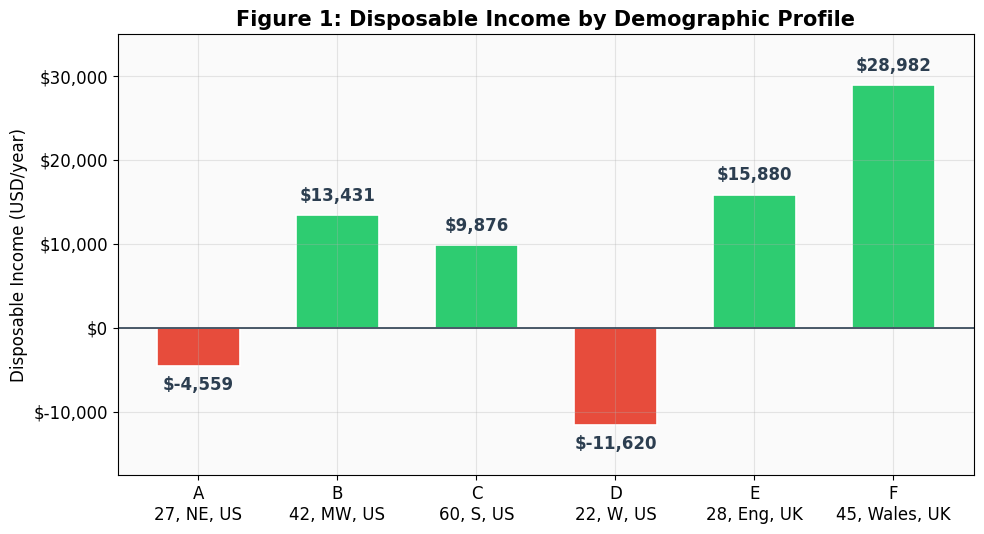

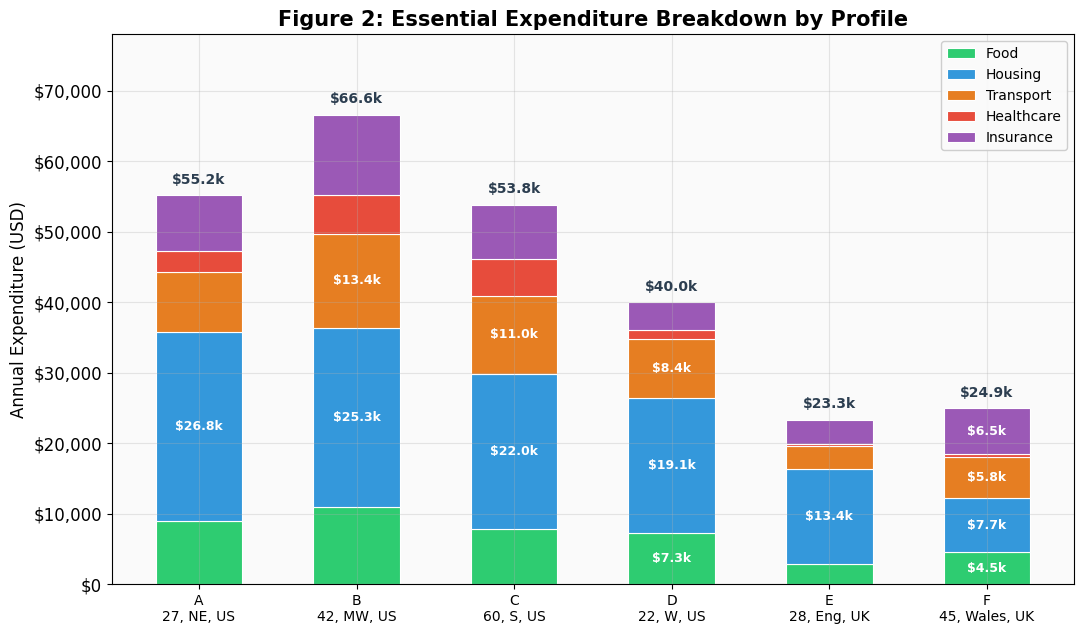

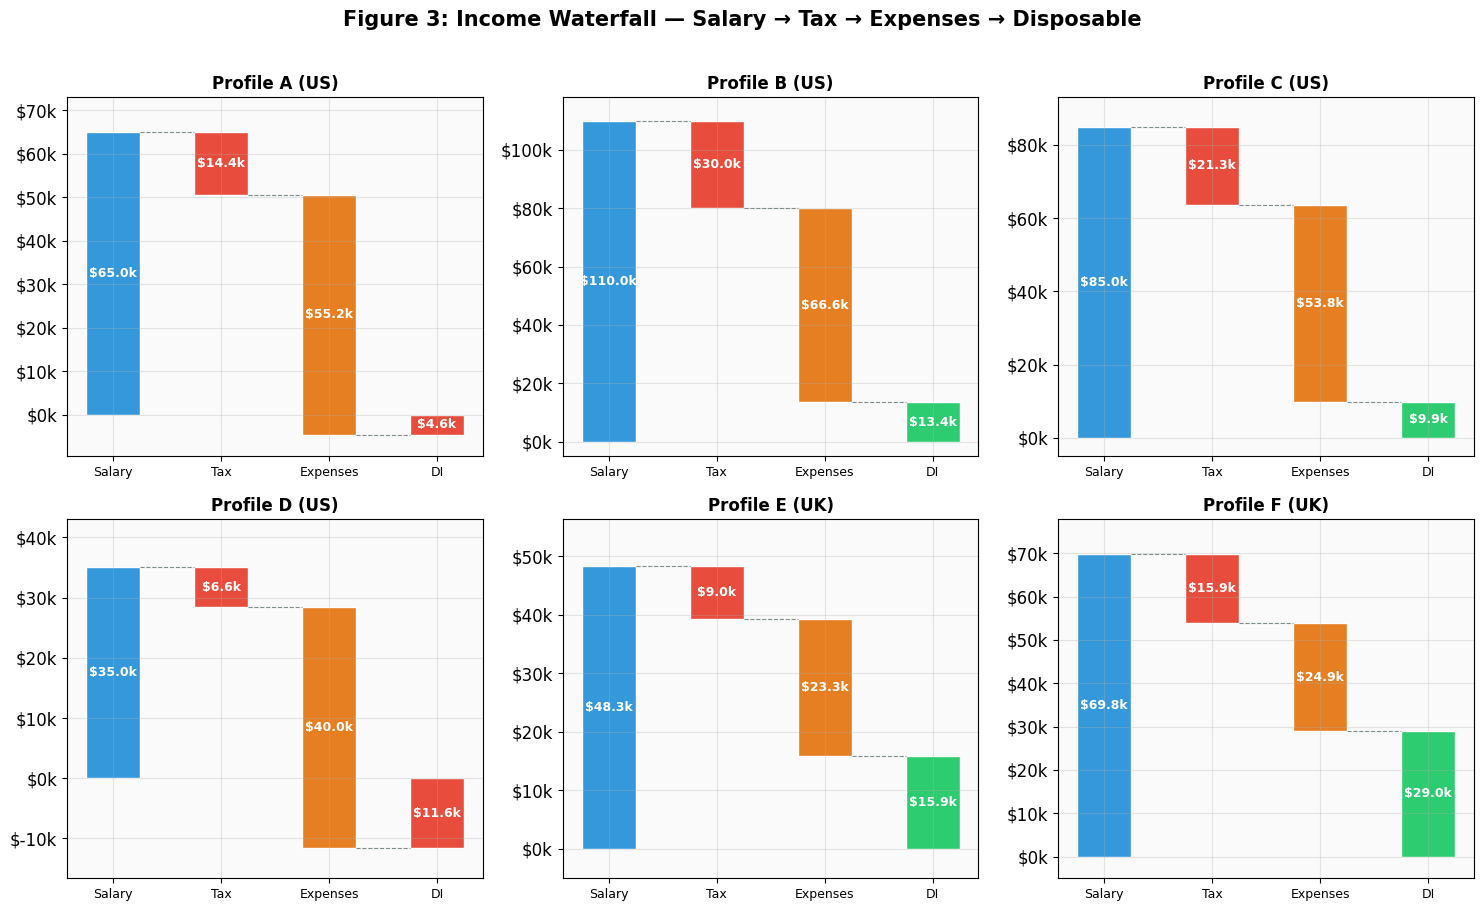

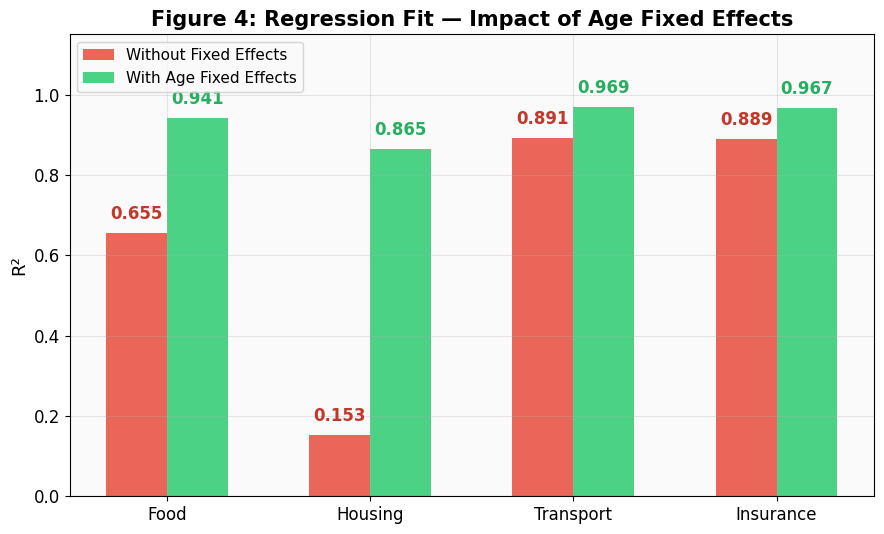

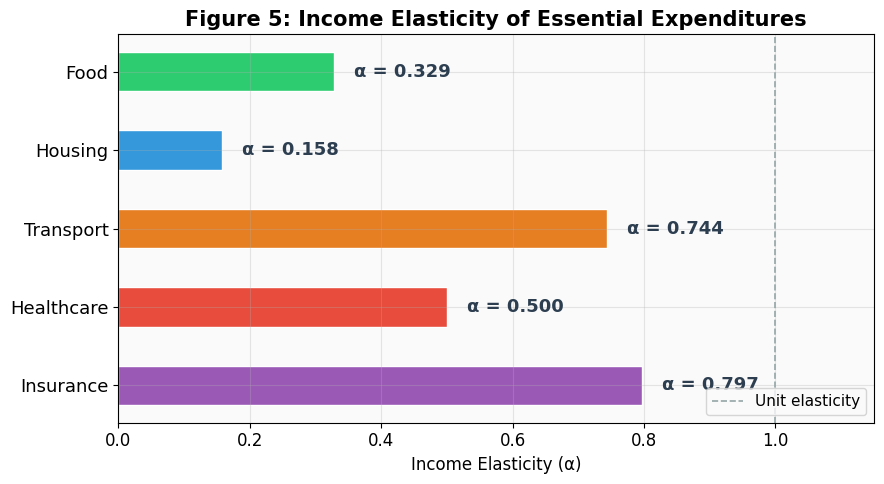

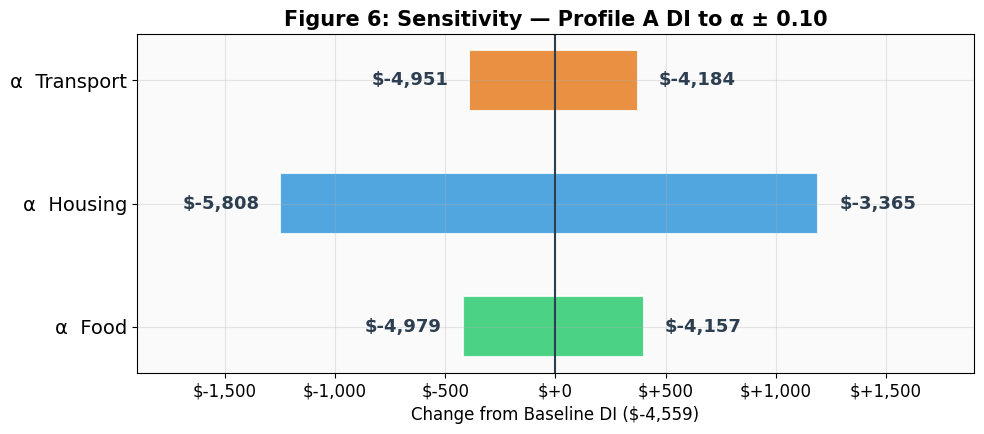


✓ Q1 complete: Tables 1–5, Figures 1–6 all produced.
  Variables 'results', 'disposable()', 'alphas', 'CATS' available for Q2/Q3.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

GBP_TO_USD = 1.27



# --- UK: Weekly income by quintile (£) ---
uk_income = np.array([272, 544, 850, 1257, 2391])

# --- UK: Weekly expenditures by age group × quintile (£) ---
uk_exp = {
  '<30':   {'Food':[35.1,36.1,53.1,55.9,58.4], 'Housing':[136.0,143.7,171.3,158.4,264.7],
            'Transport':[19.1,46.5,61.6,90.5,108.0], 'Insurance':[15.0,35.6,54.6,79.8,109.5]},
  '30-49': {'Food':[45.7,57.3,69.3,76.2,87.3], 'Housing':[103.8,133.0,124.7,110.2,126.4],
            'Transport':[29.6,51.1,74.0,97.0,134.1], 'Insurance':[28.5,46.7,72.4,102.4,162.6]},
  '50-64': {'Food':[40.2,56.8,68.0,78.3,98.6], 'Housing':[75.5,91.1,92.8,98.1,104.7],
            'Transport':[36.6,60.7,85.8,119.4,172.4], 'Insurance':[34.8,51.4,70.9,89.8,141.6]},
}

# --- UK: "All" column baselines (weekly £) ---
uk_baselines = {
  '<30':   {'Food':48.9,'Housing':173.5,'Transport':67.4,'Healthcare':3.8,'Insurance':60.8},
  '30-49': {'Food':71.7,'Housing':120.7,'Transport':88.4,'Healthcare':6.7,'Insurance':96.8},
  '50-64': {'Food':70.8,'Housing':93.4,'Transport':101.0,'Healthcare':9.7,'Insurance':82.6},
}

# --- US: BLS by age group (annual $) → TABLE 1 ---
us_age_labels = ['<25','25-34','35-44','45-54','55-64','65-74','75+']
us_income = [48514, 102494, 128285, 141121, 121571, 75460, 56028]
us_exp = {
  'Food':      [7215,9630,12460,12772,10214,8483,7168],
  'Housing':   [16853,26380,30369,30747,27019,22329,21999],
  'Transport': [9243,12802,15581,17184,15085,11414,6855],
  'Healthcare':[1485,3825,5949,6748,6711,7715,7918],
  'Insurance': [4428,10701,13465,14948,12172,4579,1908],
}
us_baseline = {ag: {'income': us_income[i], **{c: us_exp[c][i] for c in us_exp}}
               for i, ag in enumerate(us_age_labels)}

# --- US: Regional (annual $) → TABLE 2 ---
us_regions = ['Northeast','Midwest','South','West']
us_reg_exp = {
  'Food':[11372,9677,9003,11746], 'Housing':[29469,23065,23260,32147],
  'Transport':[12341,12901,12768,15463], 'Healthcare':[6289,6246,5870,6660],
  'Insurance':[10702,9665,8488,11539],
}
regional_factors = {cat: {r: round(v/np.mean(vals),3) for r, v in zip(us_regions, vals)}
                    for cat, vals in us_reg_exp.items()}

# --- UK: Regional adjustment factors ---
uk_rf = {
  'Food':      {'England':1.003,'Wales':0.951,'Scotland':0.940,'N. Ireland':1.191},
  'Housing':   {'England':1.244,'Wales':0.973,'Scotland':0.955,'N. Ireland':0.833},
  'Transport': {'England':0.987,'Wales':0.993,'Scotland':0.927,'N. Ireland':1.093},
  'Healthcare':{'England':1.012,'Wales':0.896,'Scotland':0.745,'N. Ireland':1.326},
  'Insurance': {'England':1.176,'Wales':1.024,'Scotland':0.928,'N. Ireland':0.858},
}

# --- Print TABLE 1 ---
print("TABLE 1: US Annual Expenditures by Age Group (Section 2)")
print(f"  {'Age':<8} {'Income':>10} {'Food':>8} {'Housing':>9} {'Transp':>9} {'Health':>8} {'Insur':>8}")
print("  " + "-"*62)
for i, ag in enumerate(us_age_labels):
    print(f"  {ag:<8} ${us_income[i]:>9,} ${us_exp['Food'][i]:>7,} ${us_exp['Housing'][i]:>8,} "
          f"${us_exp['Transport'][i]:>8,} ${us_exp['Healthcare'][i]:>7,} ${us_exp['Insurance'][i]:>7,}")

# --- Print TABLE 2 ---
print(f"\nTABLE 2: Regional Cost-of-Living Multipliers (Section 2)")
print(f"  {'Region':<12} {'Food':>8} {'Housing':>9} {'Transp':>9} {'Health':>9} {'Insur':>9}")
print("  " + "-"*56)
for r in us_regions:
    print(f"  {r:<12} {regional_factors['Food'][r]:>8.3f} {regional_factors['Housing'][r]:>9.3f} "
          f"{regional_factors['Transport'][r]:>9.3f} {regional_factors['Healthcare'][r]:>9.3f} "
          f"{regional_factors['Insurance'][r]:>9.3f}")

print(f"\n✓ Data loaded: UK {len(uk_exp)} age×5 quintiles, US {len(us_age_labels)} age×{len(us_regions)} regions")



age_keys = list(uk_exp.keys())
cats_reg = ['Food','Housing','Transport','Insurance']
alphas = {}
r2_new = {}

# R² values WITHOUT fixed effects (for Figure 4 comparison)
r2_old = {'Food': 0.655, 'Housing': 0.153, 'Transport': 0.891, 'Insurance': 0.889}

print("\n" + "="*60)
print("TABLE 3: Elasticities — Log-Log with Age Fixed Effects (Section 3.2)")
print("="*60)
print(f"  {'Category':<14} {'α':>7} {'R²':>7} {'n':>4}")
print("  " + "-"*34)

for cat in cats_reg:
    lnS, lnE, aid = [], [], []
    for j, age in enumerate(age_keys):
        for i in range(5):
            v = uk_exp[age][cat][i]
            if v is not None and not np.isnan(v):
                lnS.append(np.log(uk_income[i]))
                lnE.append(np.log(v))
                aid.append(j)
    n = len(lnS)
    X = np.zeros((n, 1 + len(age_keys)))
    X[:, 0] = lnS
    for k in range(n): X[k, 1 + aid[k]] = 1.0
    y = np.array(lnE)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
    alphas[cat] = round(beta[0], 3)
    r2_new[cat] = round(r2, 3)
    print(f"  {cat:<14} {beta[0]:>7.3f} {r2:>7.3f} {n:>4}")

alphas['Healthcare'] = 0.500
r2_new['Healthcare'] = None
print(f"  {'Healthcare':<14} {'0.500':>7} {'est.':>7} {'--':>4}")


def us_tax(S):
    """US: FICA + federal brackets + 5% state proxy."""
    fica = 0.062 * min(S, 168600) + 0.0145 * S
    taxable = max(S - 14600, 0)
    fed, rem = 0, taxable
    for w, r in [(11600,.10),(35550,.12),(53375,.22),(91425,.24),
                 (51775,.32),(365625,.35),(1e18,.37)]:
        fed += min(rem, w) * r; rem -= min(rem, w)
        if rem <= 0: break
    return round(fica + fed + 0.05 * S, 2)

def uk_tax(S_gbp):
    """UK: Income Tax + NI → USD."""
    it = (0.20*min(max(S_gbp-12570,0),37700) + 0.40*min(max(S_gbp-50270,0),74870)
          + 0.45*max(S_gbp-125140,0))
    ni = 0.08*min(max(S_gbp-12570,0),37700) + 0.02*max(S_gbp-50270,0)
    return round((it + ni) * GBP_TO_USD, 2)

def get_us_age(age):
    for lo, hi, lbl in [(0,25,'<25'),(25,35,'25-34'),(35,45,'35-44'),(45,55,'45-54'),
                         (55,65,'55-64'),(65,75,'65-74'),(75,200,'75+')]:
        if lo <= age < hi: return lbl

def get_uk_age(age):
    return '<30' if age < 30 else '30-49' if age < 50 else '50-64'

CATS = ['Food','Housing','Transport','Healthcare','Insurance']

def estimate(salary, age, region, country):
    """Predict annual essential expenditures (Eq. 3)."""
    if country == 'US':
        ag = get_us_age(age); b = us_baseline[ag]; ratio = salary / b['income']
        return {c: b[c] * ratio**alphas[c] * regional_factors[c].get(region,1) for c in CATS}
    else:
        sal_gbp = salary / GBP_TO_USD
        ag = get_uk_age(age); ratio = (sal_gbp/52) / np.mean(uk_income)
        return {c: uk_baselines[ag][c]*52 * ratio**alphas[c] * uk_rf[c].get(region,1) * GBP_TO_USD
                for c in CATS}

def disposable(salary, age, region, country):
    """Compute disposable income (Eq. 5)."""
    sal_usd = salary if country == 'US' else salary * GBP_TO_USD
    tax = us_tax(salary) if country == 'US' else uk_tax(salary)
    exp = estimate(sal_usd, age, region, country)
    aft = sal_usd - tax
    return {'salary':sal_usd, 'tax':tax, 'after_tax':aft,
            'expenses':exp, 'total_exp':sum(exp.values()), 'DI':aft - sum(exp.values())}


profiles = [('A',27,65000,'Northeast','US'), ('B',42,110000,'Midwest','US'),
            ('C',60,85000,'South','US'),     ('D',22,35000,'West','US'),
            ('E',28,38000,'England','UK'),   ('F',45,55000,'Wales','UK')]

print("\n" + "="*80)
print("TABLE 4: Disposable Income Results (Section 4)")
print("="*80)
print(f"{'ID':<4} {'Salary':>10} {'Tax':>10} {'After-Tax':>10} {'Essentials':>10} {'DI':>12}")
print("-"*80)
results = {}
for nm, age, sal, reg, ctry in profiles:
    r = disposable(sal, age, reg, ctry)
    results[nm] = r
    print(f" {nm:<3} ${r['salary']:>9,.0f} ${r['tax']:>9,.0f} ${r['after_tax']:>9,.0f} "
          f"${r['total_exp']:>9,.0f}  ${r['DI']:>10,.0f}")


print("\n" + "="*80)
print("WORKED EXAMPLE: Profile A (Age 27, $65K, Northeast) — Section 4.1")
print("="*80)
r = results['A']; ag = '25-34'; ratio = 65000/us_baseline[ag]['income']
print(f"  Tax = ${r['tax']:,.0f}  |  After-tax = ${r['after_tax']:,.0f}")
print(f"  Age group: {ag}, mean income = ${us_baseline[ag]['income']:,}, ratio = {ratio:.3f}")
for c in CATS:
    b = us_baseline[ag][c]; a = alphas[c]; rf = regional_factors[c]['Northeast']
    print(f"  E_{c:<12} = {b:>6,} × {ratio:.3f}^{a:.3f} × {rf:.3f} = ${r['expenses'][c]:>8,.0f}")
print(f"  Total = ${r['total_exp']:,.0f}  →  DI = ${r['DI']:,.0f}")


print("\n" + "="*80)
print("TABLE 5: Sensitivity — α ± 0.10, Profile A (Section 5)")
print("="*80)
print(f"  {'Parameter':<20} {'α−0.10':>10} {'Baseline':>10} {'α+0.10':>10}")
bdi = results['A']['DI']
sens_lo = []; sens_hi = []; sens_cats_list = ['Food','Housing','Transport']
for cat in sens_cats_list:
    orig = alphas[cat]
    alphas[cat] = orig - 0.10; lo = disposable(65000,27,'Northeast','US')['DI']
    alphas[cat] = orig + 0.10; hi = disposable(65000,27,'Northeast','US')['DI']
    alphas[cat] = orig
    sens_lo.append(lo); sens_hi.append(hi)
    print(f"  α_{cat:<17} ${lo:>9,.0f} ${bdi:>9,.0f} ${hi:>9,.0f}")


plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#fafafa',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 12,
    'axes.titlesize': 15, 'axes.titleweight': 'bold',
})

# --- Collect plotting data from results ---
prof_labels = ['A\n27, NE, US','B\n42, MW, US','C\n60, S, US',
               'D\n22, W, US','E\n28, Eng, UK','F\n45, Wales, UK']
short = ['A','B','C','D','E','F']
salary_vals = [results[n]['salary'] for n in short]
tax_vals    = [results[n]['tax'] for n in short]
di_vals     = [results[n]['DI'] for n in short]
exp_data    = {c: [results[n]['expenses'][c] for n in short] for c in CATS}
colors_exp  = ['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6']

fig1, ax1 = plt.subplots(figsize=(10, 5.5))
bar_colors = ['#e74c3c' if d < 0 else '#2ecc71' for d in di_vals]
bars = ax1.bar(prof_labels, di_vals, color=bar_colors, edgecolor='white', linewidth=1.2, width=0.6)
ax1.axhline(0, color='#2c3e50', linewidth=1.2)
for bar, val in zip(bars, di_vals):
    y = bar.get_height()
    offset = 1200 if val >= 0 else -1200
    ax1.text(bar.get_x()+bar.get_width()/2, y+offset, f'${val:,.0f}',
             ha='center', va='bottom' if val >= 0 else 'top',
             fontweight='bold', fontsize=12, color='#2c3e50')
ax1.set_ylabel('Disposable Income (USD/year)', fontsize=12)
ax1.set_title('Figure 1: Disposable Income by Demographic Profile')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylim(min(di_vals)-6000, max(di_vals)+6000)
fig1.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(short)); bottom = np.zeros(len(short))
for i, cat in enumerate(CATS):
    vals = np.array(exp_data[cat])
    ax2.bar(x, vals, bottom=bottom, label=cat, color=colors_exp[i],
            edgecolor='white', linewidth=0.8, width=0.55)
    for j in range(len(short)):
        total_j = sum(exp_data[c][j] for c in CATS)
        if vals[j]/total_j > 0.18:
            ax2.text(x[j], bottom[j]+vals[j]/2, f'${vals[j]/1000:.1f}k',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += vals
for j in range(len(short)):
    total = sum(exp_data[c][j] for c in CATS)
    ax2.text(x[j], total+1200, f'${total/1000:.1f}k', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#2c3e50')
ax2.set_xticks(x); ax2.set_xticklabels(prof_labels, fontsize=10)
ax2.set_ylabel('Annual Expenditure (USD)', fontsize=12)
ax2.set_title('Figure 2: Essential Expenditure Breakdown by Profile')
ax2.legend(loc='upper right', framealpha=0.95, fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylim(0, 78000)
fig2.tight_layout(); plt.show()

ctry_list = ['US','US','US','US','UK','UK']
for idx in range(6):
    ax = axes3[idx//3][idx%3]
    nm = short[idx]; s = salary_vals[idx]; t = tax_vals[idx]
    e = sum(exp_data[c][idx] for c in CATS); d = di_vals[idx]
    segments = ['Salary','Tax','Expenses','DI']
    values = [s, -t, -e, d]
    bottoms = [0, s, s-t, 0]; tops = [s, s-t, s-t-e, d]
    seg_colors = ['#3498db','#e74c3c','#e67e22','#2ecc71' if d >= 0 else '#e74c3c']
    for k in range(4):
        b = min(bottoms[k], tops[k]); h = abs(values[k])
        ax.bar(segments[k], h, bottom=b, color=seg_colors[k], edgecolor='white', width=0.5)
        ax.text(k, b+h/2, f'${abs(values[k])/1000:.1f}k', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    for k in range(3):
        ax.plot([k+0.25, k+0.75], [tops[k], tops[k]], color='#7f8c8d', linewidth=0.8, linestyle='--')
    ax.set_title(f'Profile {nm} ({ctry_list[idx]})', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_ylim(min(0, d)-5000, s+8000); ax.tick_params(axis='x', labelsize=9)
fig3.suptitle('Figure 3: Income Waterfall — Salary → Tax → Expenses → Disposable',
              fontsize=15, fontweight='bold', y=1.01)
fig3.tight_layout(); plt.show()

fig4, ax4 = plt.subplots(figsize=(9, 5.5))
plot_cats = cats_reg  # Food, Housing, Transport, Insurance
old_v = [r2_old[c] for c in plot_cats]
new_v = [r2_new[c] for c in plot_cats]
x4 = np.arange(len(plot_cats)); w = 0.3
bars_old = ax4.bar(x4-w/2, old_v, w, label='Without Fixed Effects', color='#e74c3c', alpha=0.85)
bars_new = ax4.bar(x4+w/2, new_v, w, label='With Age Fixed Effects', color='#2ecc71', alpha=0.85)
for bar in bars_old:
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.025,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=12,
             fontweight='bold', color='#c0392b')
for bar in bars_new:
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.025,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=12,
             fontweight='bold', color='#27ae60')
ax4.set_xticks(x4); ax4.set_xticklabels(plot_cats, fontsize=12)
ax4.set_ylabel('R²', fontsize=13)
ax4.set_title('Figure 4: Regression Fit — Impact of Age Fixed Effects')
ax4.set_ylim(0, 1.15); ax4.legend(fontsize=11, loc='upper left')
fig4.tight_layout(); plt.show()

fig5, ax5 = plt.subplots(figsize=(9, 5))
alpha_list = [alphas[c] for c in CATS]
ebar_colors = ['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6']
bars5 = ax5.barh(CATS[::-1], alpha_list[::-1], color=ebar_colors[::-1], height=0.5, edgecolor='white')
for bar, val in zip(bars5, alpha_list[::-1]):
    ax5.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2,
             f'α = {val:.3f}', va='center', fontweight='bold', fontsize=13, color='#2c3e50')
ax5.axvline(1.0, color='#95a5a6', linestyle='--', linewidth=1.2, label='Unit elasticity')
ax5.set_xlabel('Income Elasticity (α)', fontsize=12)
ax5.set_title('Figure 5: Income Elasticity of Essential Expenditures')
ax5.set_xlim(0, 1.15); ax5.tick_params(axis='y', labelsize=13)
ax5.legend(loc='lower right', fontsize=11)
fig5.tight_layout(); plt.show()
fig6, ax6 = plt.subplots(figsize=(10, 4.5))
y6 = np.arange(len(sens_cats_list)); tornado_colors = ['#2ecc71','#3498db','#e67e22']
for i in range(len(sens_cats_list)):
    lo_delta = sens_lo[i] - bdi; hi_delta = sens_hi[i] - bdi
    left_edge = min(lo_delta, hi_delta); width = abs(hi_delta - lo_delta)
    ax6.barh(y6[i], width, left=left_edge, color=tornado_colors[i],
             height=0.5, edgecolor='white', linewidth=1.5, alpha=0.85)
for i in range(len(sens_cats_list)):
    lo_delta = sens_lo[i] - bdi; hi_delta = sens_hi[i] - bdi
    ax6.annotate(f'${sens_lo[i]:,.0f}', xy=(lo_delta, y6[i]),
                 xytext=(-15,0), textcoords='offset points',
                 ha='right', va='center', fontsize=13, fontweight='bold', color='#2c3e50')
    ax6.annotate(f'${sens_hi[i]:,.0f}', xy=(hi_delta, y6[i]),
                 xytext=(15,0), textcoords='offset points',
                 ha='left', va='center', fontsize=13, fontweight='bold', color='#2c3e50')
ax6.axvline(0, color='#2c3e50', linewidth=1.5)
ax6.set_yticks(y6); ax6.set_yticklabels([f'α  {c}' for c in sens_cats_list], fontsize=14)
ax6.set_xlabel(f'Change from Baseline DI (${bdi:,.0f})', fontsize=12)
ax6.set_title('Figure 6: Sensitivity — Profile A DI to α ± 0.10')
ax6.set_xlim(-1900, 1900)
ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
fig6.tight_layout(); plt.show()

print("\n✓ Q1 complete: Tables 1–5, Figures 1–6 all produced.")
print("  Variables 'results', 'disposable()', 'alphas', 'CATS' available for Q2/Q3.")

Simulating 30-year savings trajectories (Section 7.2)...
      No gambling: median = $217,388, P(debt) = 0.0%
           Risk 1: median = $210,356, P(debt) = 0.0%
           Risk 3: median = $182,546, P(debt) = 0.0%
           Risk 5: median = $-15,261, P(debt) = 74.1%

TABLE 9: 30-Year Financial Outcomes (Section 7.3)
  Scenario                     Median     10th pct     90th pct   P(debt)          Gap
  --------------------------------------------------------------------------------
  No gambling            $    217,388 $    111,986 $    437,587      0.0% $          0
  Risk 1                 $    210,356 $    108,612 $    425,775      0.0% $      7,032
  Risk 3                 $    182,546 $     93,432 $    367,906      0.0% $     34,842
  Risk 5                 $    -15,261 $    -65,218 $     17,717     74.1% $    232,649

TABLE 10: Fraction Losing >X% of DI in One Year (Section 7.5)
   Risk       >5%      >10%      >25%      >50%
  ---------------------------------------------
  

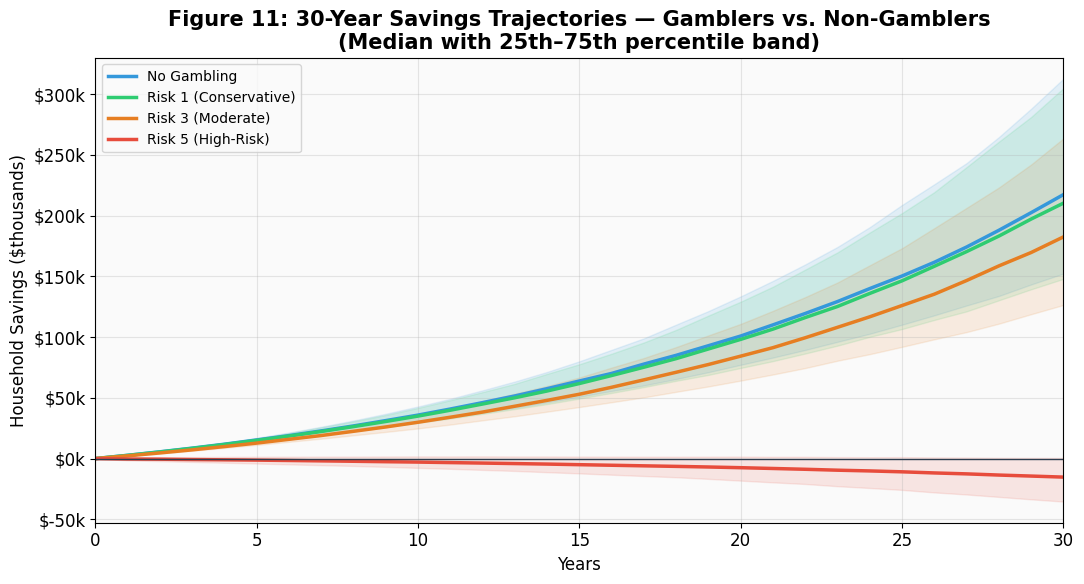

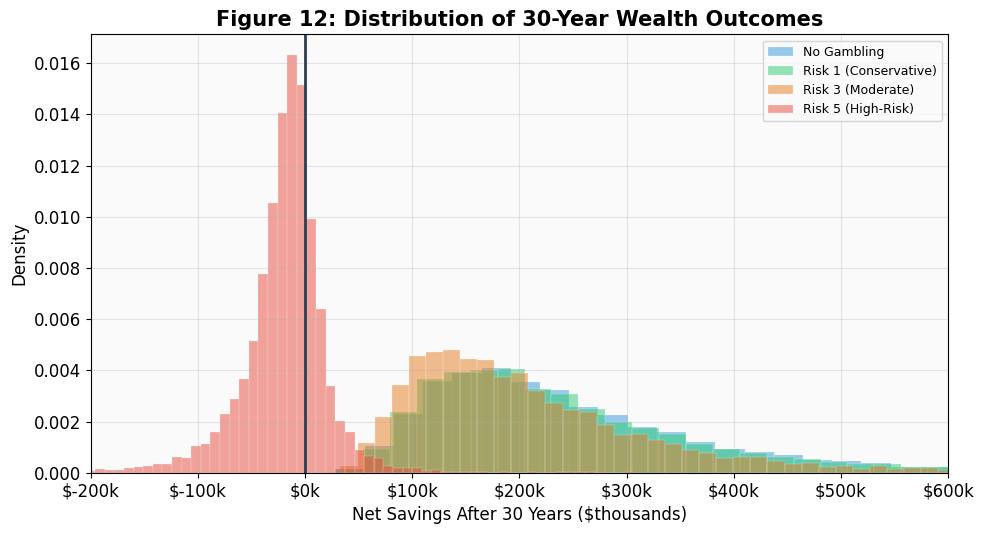

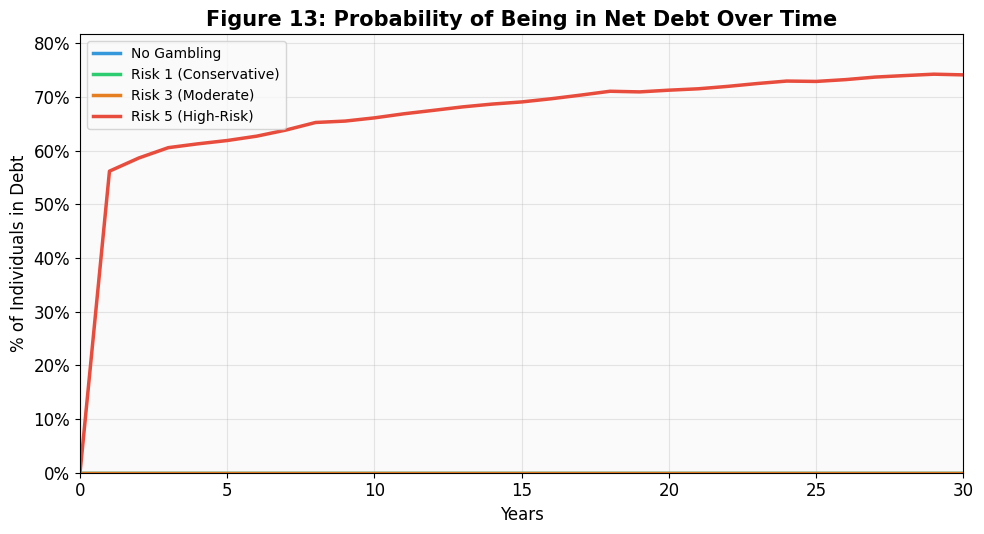

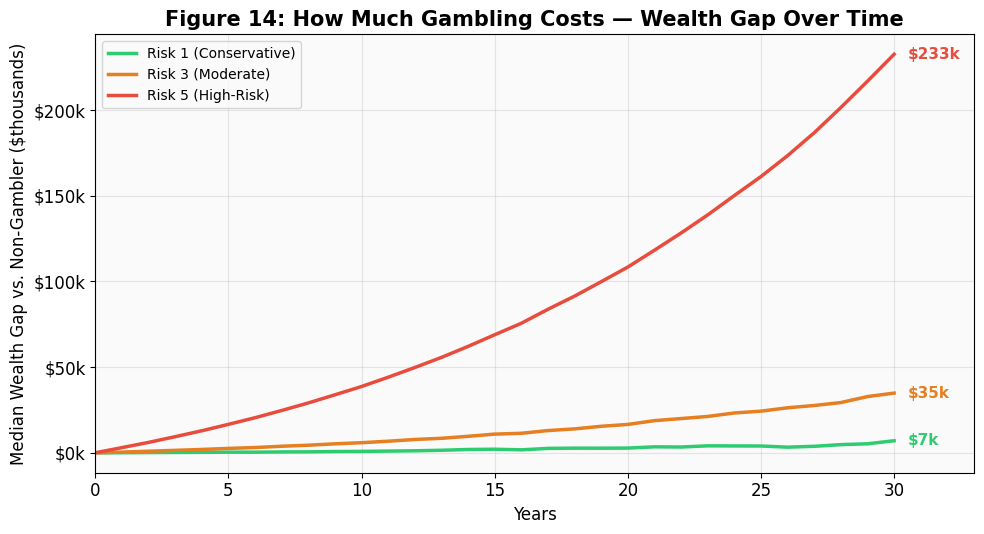

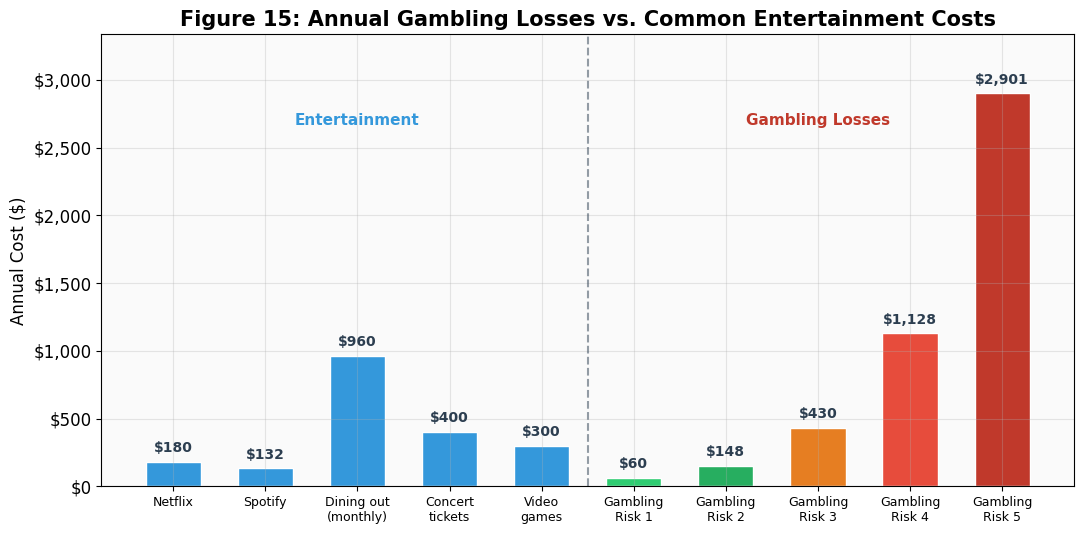

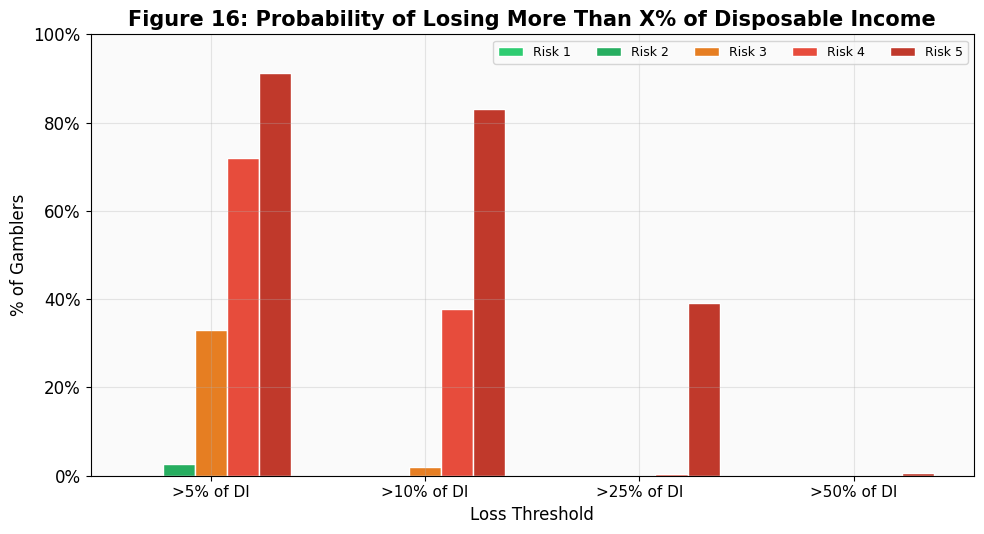


✓ Q3 complete: Tables 9–11, Figures 11–16 all produced.
✓ ALL THREE QUESTIONS COMPLETE — every table and figure from the paper is here.


In [ ]:


np.random.seed(42)


BASE_WAGER_FRAC_Q3 = 0.10
RISK_MULT  = {1: 1.0, 2: 2.0, 3: 4.0, 4: 7.0, 5: 12.0}
EDGE       = {1: 0.045, 2: 0.055, 3: 0.08, 4: 0.12, 5: 0.18}
BETS_Q3    = {1: 50, 2: 100, 3: 200, 4: 350, 5: 500}
PAYOUT     = {1: 1.0, 2: 1.0, 3: 1.5, 4: 3.0, 5: 6.0}

def annual_wager_q3(di, risk):
    if di <= 0: return 2000 * RISK_MULT[risk]
    return di * BASE_WAGER_FRAC_Q3 * RISK_MULT[risk]

def expected_loss_q3(di, risk):
    return annual_wager_q3(di, risk) * EDGE[risk]

def simulate_year_pnl(di, risk, n_sims=50000):
    """Simulate one year's gambling P&L for n_sims individuals."""
    w = annual_wager_q3(di, risk)
    n = BETS_Q3[risk]; bet = w / n; k = PAYOUT[risk]
    p = (1 - EDGE[risk]) / (1 + k)
    wins = np.random.binomial(n, p, size=n_sims)
    return wins * k * bet - (n - wins) * bet


DI = 13431
SAVE_RATE = 0.20
ANNUAL_SAVING = DI * SAVE_RATE   # $2,686/yr baseline
R_MEAN = 0.07; R_STD = 0.15
N_SIMS = 10000; N_YEARS = 30

def simulate_savings_trajectory(risk_level, n_sims=N_SIMS, n_years=N_YEARS):
    """Simulate 30-year wealth trajectories (Eq. 8)."""
    wealth = np.zeros((n_sims, n_years + 1))
    for t in range(n_years):
        r_t = np.random.normal(R_MEAN, R_STD, size=n_sims)
        if risk_level == 0:
            g_t = np.zeros(n_sims)
        else:
            g_t = -simulate_year_pnl(DI, risk_level, n_sims)  # + = loss, − = win
        wealth[:, t+1] = wealth[:, t] * (1 + r_t) + (ANNUAL_SAVING - g_t)
    return wealth

# --- Run simulations ---
print("Simulating 30-year savings trajectories (Section 7.2)...")
trajectories = {}
for risk in [0, 1, 3, 5]:
    trajectories[risk] = simulate_savings_trajectory(risk)
    med = np.median(trajectories[risk][:, -1])
    p_neg = np.mean(trajectories[risk][:, -1] < 0) * 100
    label = f"Risk {risk}" if risk > 0 else "No gambling"
    print(f"  {label:>15}: median = ${med:,.0f}, P(debt) = {p_neg:.1f}%")

print("\n" + "="*85)
print("TABLE 9: 30-Year Financial Outcomes (Section 7.3)")
print("="*85)
print(f"  {'Scenario':<22} {'Median':>12} {'10th pct':>12} {'90th pct':>12} {'P(debt)':>9} {'Gap':>12}")
print("  " + "-"*80)
for risk in [0, 1, 3, 5]:
    w = trajectories[risk][:, -1]
    label = f"Risk {risk}" if risk > 0 else "No gambling"
    gap = np.median(trajectories[0][:, -1]) - np.median(w) if risk > 0 else 0
    print(f"  {label:<22} ${np.median(w):>11,.0f} ${np.percentile(w,10):>11,.0f} "
          f"${np.percentile(w,90):>11,.0f} {np.mean(w<0)*100:>8.1f}% ${gap:>11,.0f}")

print("\n" + "="*70)
print("TABLE 10: Fraction Losing >X% of DI in One Year (Section 7.5)")
print("="*70)
thresholds_pct = [5, 10, 25, 50]
print(f"  {'Risk':>5}", end="")
for t in thresholds_pct:
    print(f"  {'>'+str(t)+'%':>8}", end="")
print()
print("  " + "-"*45)
for risk in [1, 2, 3, 4, 5]:
    pnl = simulate_year_pnl(DI, risk)
    losses_pct = -pnl / DI * 100
    print(f"  {risk:>5}", end="")
    for t in thresholds_pct:
        print(f"  {np.mean(losses_pct > t)*100:>7.1f}%", end="")
    print()
]

print("\n" + "="*85)
print("TABLE 11: Summary of Findings Across All Three Questions (Section 8)")
print("="*85)
print(f"  {'Question':<8} {'Finding':<75}")
print("  " + "-"*80)
print(f"  {'Q1':<8} {'DI ranges from -$11,620 (Profile D) to +$28,982 (Profile F)':<75}")
print(f"  {'':<8} {'UK profiles outperform US at similar salary due to lower housing/healthcare':<75}")
print(f"  {'Q2':<8} {'Conservative gambler loses ~$60/yr; aggressive loses $2,901 (22% of DI)':<75}")
print(f"  {'':<8} {'Population-level model reproduces $15B industry revenue within 3%':<75}")
print(f"  {'Q3':<8} {'Risk 5 gambler: 74% chance of debt after 30 years':<75}")
gap_r5 = np.median(trajectories[0][:, -1]) - np.median(trajectories[5][:, -1])
print(f"  {'':<8} {'Median wealth gap at 30 years: $' + f'{gap_r5:,.0f} for high-risk gamblers':<75}")

years = np.arange(N_YEARS + 1)
colors_q3 = {0: '#3498db', 1: '#2ecc71', 3: '#e67e22', 5: '#e74c3c'}
labels_q3 = {0: 'No Gambling', 1: 'Risk 1 (Conservative)',
             3: 'Risk 3 (Moderate)', 5: 'Risk 5 (High-Risk)'}

fig11, ax = plt.subplots(figsize=(11, 6))
for risk in [0, 1, 3, 5]:
    w = trajectories[risk]
    med = np.median(w, axis=0); p25 = np.percentile(w, 25, axis=0); p75 = np.percentile(w, 75, axis=0)
    ax.plot(years, med/1000, color=colors_q3[risk], linewidth=2.5, label=labels_q3[risk])
    ax.fill_between(years, p25/1000, p75/1000, color=colors_q3[risk], alpha=0.12)
ax.axhline(0, color='#2c3e50', linewidth=1, linestyle='-')
ax.set_xlabel('Years', fontsize=12); ax.set_ylabel('Household Savings ($thousands)', fontsize=12)
ax.set_title('Figure 11: 30-Year Savings Trajectories — Gamblers vs. Non-Gamblers\n'
             '(Median with 25th–75th percentile band)')
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}k'))
ax.set_xlim(0, 30)
fig11.tight_layout(); plt.show()

fig12, ax2 = plt.subplots(figsize=(10, 5.5))
for risk in [0, 1, 3, 5]:
    final = trajectories[risk][:, -1] / 1000
    ax2.hist(final, bins=80, color=colors_q3[risk], alpha=0.5, density=True,
             label=labels_q3[risk], edgecolor='white', linewidth=0.3)
ax2.axvline(0, color='#2c3e50', linewidth=2, linestyle='-')
ax2.set_xlabel('Net Savings After 30 Years ($thousands)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Figure 12: Distribution of 30-Year Wealth Outcomes')
ax2.legend(fontsize=9, loc='upper right')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}k'))
ax2.set_xlim(-200, 600)
fig12.tight_layout(); plt.show()

fig13, ax3 = plt.subplots(figsize=(10, 5.5))
for risk in [0, 1, 3, 5]:
    p_debt = np.mean(trajectories[risk] < 0, axis=0) * 100
    ax3.plot(years, p_debt, color=colors_q3[risk], linewidth=2.5, label=labels_q3[risk])
ax3.set_xlabel('Years', fontsize=12); ax3.set_ylabel('% of Individuals in Debt', fontsize=12)
ax3.set_title('Figure 13: Probability of Being in Net Debt Over Time')
ax3.legend(fontsize=10, loc='upper left')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax3.set_xlim(0, 30); ax3.set_ylim(0, max(np.mean(trajectories[5] < 0, axis=0))*110)
fig13.tight_layout(); plt.show()

fig14, ax4 = plt.subplots(figsize=(10, 5.5))
baseline_median = np.median(trajectories[0], axis=0)
for risk in [1, 3, 5]:
    gap = (baseline_median - np.median(trajectories[risk], axis=0)) / 1000
    ax4.plot(years, gap, color=colors_q3[risk], linewidth=2.5, label=labels_q3[risk])
    ax4.text(30.5, gap[-1], f'${gap[-1]:,.0f}k', color=colors_q3[risk],
             fontsize=11, fontweight='bold', va='center')
ax4.set_xlabel('Years', fontsize=12)
ax4.set_ylabel('Median Wealth Gap vs. Non-Gambler ($thousands)', fontsize=12)
ax4.set_title('Figure 14: How Much Gambling Costs — Wealth Gap Over Time')
ax4.legend(fontsize=10, loc='upper left')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}k'))
ax4.set_xlim(0, 33)
fig14.tight_layout(); plt.show()

fig15, ax5 = plt.subplots(figsize=(11, 5.5))
entertainment = {'Netflix': 180, 'Spotify': 132, 'Dining out\n(monthly)': 960,
                 'Concert\ntickets': 400, 'Video\ngames': 300}
gambling_losses = {f'Gambling\nRisk {r}': expected_loss_q3(DI, r) for r in [1,2,3,4,5]}
ent_names = list(entertainment.keys()); ent_vals = list(entertainment.values())
all_names = ent_names + list(gambling_losses.keys())
all_vals  = ent_vals + list(gambling_losses.values())
bar_colors_ent = ['#3498db']*5 + ['#2ecc71','#27ae60','#e67e22','#e74c3c','#c0392b']

bars15 = ax5.bar(range(len(all_names)), all_vals, color=bar_colors_ent, width=0.6, edgecolor='white')
ax5.axvline(4.5, color='#2c3e50', linewidth=1.5, linestyle='--', alpha=0.5)
ax5.text(2, max(all_vals)*0.92, 'Entertainment', ha='center', fontsize=11,
         color='#3498db', fontweight='bold')
ax5.text(7, max(all_vals)*0.92, 'Gambling Losses', ha='center', fontsize=11,
         color='#c0392b', fontweight='bold')
for bar, val in zip(bars15, all_vals):
    ax5.text(bar.get_x()+bar.get_width()/2, val+50, f'${val:,.0f}', ha='center',
             va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')
ax5.set_xticks(range(len(all_names))); ax5.set_xticklabels(all_names, fontsize=9)
ax5.set_ylabel('Annual Cost ($)', fontsize=12)
ax5.set_title('Figure 15: Annual Gambling Losses vs. Common Entertainment Costs')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax5.set_ylim(0, max(all_vals)*1.15)
fig15.tight_layout(); plt.show()

fig16, ax6 = plt.subplots(figsize=(10, 5.5))
x16 = np.arange(len(thresholds_pct)); width16 = 0.15
risk_list = [1, 2, 3, 4, 5]
rc = ['#2ecc71','#27ae60','#e67e22','#e74c3c','#c0392b']
for i, risk in enumerate(risk_list):
    pnl = simulate_year_pnl(DI, risk)
    losses_pct = -pnl / DI * 100
    probs = [np.mean(losses_pct > t) * 100 for t in thresholds_pct]
    ax6.bar(x16 + i*width16 - 2*width16, probs, width16,
            label=f'Risk {risk}', color=rc[i], edgecolor='white')
ax6.set_xticks(x16); ax6.set_xticklabels([f'>{t}% of DI' for t in thresholds_pct], fontsize=11)
ax6.set_ylabel('% of Gamblers', fontsize=12)
ax6.set_xlabel('Loss Threshold', fontsize=12)
ax6.set_title('Figure 16: Probability of Losing More Than X% of Disposable Income')
ax6.legend(fontsize=9, ncol=5, loc='upper right')
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax6.set_ylim(0, 100)
fig16.tight_layout(); plt.show()

print("\n✓ Q3 complete: Tables 9–11, Figures 11–16 all produced.")
print("✓ ALL THREE QUESTIONS COMPLETE — every table and figure from the paper is here.")